# IDS Transformer — Dataset Personnel
### Modèle Transformer temporel pour détection d'intrusion
**Classes** : Benign · Botnet · Brute_SSH · Port_Scan · Slowloris · Vul_Scan

## 1. Imports

In [1]:
!pip install imbalanced-learn -q

import numpy as np
import pandas as pd
import gc
import os
import warnings
import random
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import joblib

warnings.filterwarnings('ignore')

# Reproducibilité
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print('✅ Imports OK')
print(f'PyTorch : {torch.__version__}')
print(f'GPU disponible : {torch.cuda.is_available()}')


✅ Imports OK
PyTorch : 2.10.0+cpu
GPU disponible : False


## 2. Chemins des fichiers CSV

In [2]:
# ============================================================
# CHEMINS DES CSV — À REMPLIR
# ============================================================
CSV_FILES = {
    # Label     :  chemin du fichier
    'Benign'    : '/kaggle/input/datasets/morsifeki1/newdata/dataset_benign.csv',   # ← dataset_benign.csv
    'Botnet'    : '/kaggle/input/datasets/morsifeki1/newdata/dataset_botnet.csv',   # ← dataset_botnet.csv
    'Botnet'    : '/kaggle/input/datasets/morsifeki1/newdata/dataset_botnet2.csv',   # ← dataset_botnet2.csv  (sera mergé avec Botnet)
    'Botnet'    : '/kaggle/input/datasets/morsifeki1/newdata/dataset_botnet3.csv',   # ← dataset_botnet3.csv
    'Brute_SSH' : '/kaggle/input/datasets/morsifeki1/newdata/dataset_brute_ssh.csv',   # ← dataset_brute_ssh.csv
    'Port_Scan' : '/kaggle/input/datasets/morsifeki1/newdata/dataset_port_scan.csv',   # ← dataset_port_scan.csv
    'Port_Scan' : '/kaggle/input/datasets/morsifeki1/newdata/dataset_port_scan2.csv',   # ← dataset_port_scan2.csv
    'Slowloris' : '/kaggle/input/datasets/morsifeki1/newdata/dataset_Slowloris.csv',   # ← dataset_Slowloris.csv
    'Vul_Scan'  : '/kaggle/input/datasets/morsifeki1/newdata/dataset_Vul_scan.csv',   # ← dataset_Vul_scan.csv
}

# IPs attaquant / victime
ATTACKER_IP = '192.168.10.50'
VICTIM_IP   = '192.168.50.100'

print('Chemins définis.')

Chemins définis.


## 3. Chargement et labellisation automatique

In [3]:
# ============================================================
# Fichiers groupés par label (plusieurs CSV → même label)
# ============================================================
LABEL_FILES = {
    'Benign'    : ['/kaggle/input/datasets/morsifeki1/newdata/dataset_benign.csv'],   # ← dataset_benign.csv
    'Botnet'    : ['/kaggle/input/datasets/morsifeki1/newdata/dataset_botnet.csv', '/kaggle/input/datasets/morsifeki1/newdata/dataset_botnet2.csv', '/kaggle/input/datasets/morsifeki1/newdata/dataset_botnet3.csv'],  # ← botnet.csv, botnet2.csv, botnet3.csv
    'Brute_SSH' : ['/kaggle/input/datasets/morsifeki1/newdata/dataset_brute_ssh.csv'],   # ← dataset_brute_ssh.csv
    'Port_Scan' : ['/kaggle/input/datasets/morsifeki1/newdata/dataset_port_scan.csv', '/kaggle/input/datasets/morsifeki1/newdata/dataset_port_scan2.csv'],  # ← port_scan.csv, port_scan2.csv
    'Slowloris' : ['/kaggle/input/datasets/morsifeki1/newdata/dataset_Slowloris.csv'],   # ← dataset_Slowloris.csv
    'Vul_Scan'  : ['/kaggle/input/datasets/morsifeki1/newdata/dataset_Vul_scan.csv'],   # ← dataset_Vul_scan.csv
}

ATTACKER_IP = '192.168.10.50'
VICTIM_IP   = '192.168.50.100'

# ============================================================
# Features attendues (CICFlowMeter custom)
# ============================================================
FEATURE_COLS = [
    'src_port', 'dst_port', 'protocol', 'flow_duration',
    'flow_byts_s', 'flow_pkts_s', 'fwd_pkts_s', 'bwd_pkts_s',
    'tot_fwd_pkts', 'tot_bwd_pkts', 'totlen_fwd_pkts', 'totlen_bwd_pkts',
    'fwd_pkt_len_max', 'fwd_pkt_len_min', 'fwd_pkt_len_mean', 'fwd_pkt_len_std',
    'bwd_pkt_len_max', 'bwd_pkt_len_min', 'bwd_pkt_len_mean', 'bwd_pkt_len_std',
    'pkt_len_max', 'pkt_len_min', 'pkt_len_mean', 'pkt_len_std', 'pkt_len_var',
    'fwd_header_len', 'bwd_header_len', 'fwd_seg_size_min', 'fwd_act_data_pkts',
    'flow_iat_mean', 'flow_iat_max', 'flow_iat_min', 'flow_iat_std',
    'fwd_iat_tot', 'fwd_iat_max', 'fwd_iat_min', 'fwd_iat_mean', 'fwd_iat_std',
    'bwd_iat_tot', 'bwd_iat_max', 'bwd_iat_min', 'bwd_iat_mean', 'bwd_iat_std',
    'fwd_psh_flags', 'bwd_psh_flags', 'fwd_urg_flags', 'bwd_urg_flags',
    'fin_flag_cnt', 'syn_flag_cnt', 'rst_flag_cnt', 'psh_flag_cnt',
    'ack_flag_cnt', 'urg_flag_cnt', 'ece_flag_cnt',
    'down_up_ratio', 'pkt_size_avg', 'init_fwd_win_byts', 'init_bwd_win_byts',
    'active_max', 'active_min', 'active_mean', 'active_std',
    'idle_max', 'idle_min', 'idle_mean', 'idle_std',
    'fwd_byts_b_avg', 'fwd_pkts_b_avg', 'bwd_byts_b_avg', 'bwd_pkts_b_avg',
    'fwd_blk_rate_avg', 'bwd_blk_rate_avg',
    'fwd_seg_size_avg', 'bwd_seg_size_avg',
    'cwr_flag_count', 'subflow_fwd_pkts', 'subflow_bwd_pkts',
    'subflow_fwd_byts', 'subflow_bwd_byts'
]

# ============================================================
# Chargement + labellisation
# ============================================================
df_parts = []

for label, paths in LABEL_FILES.items():
    for path in paths:
        if not path or not os.path.exists(path):
            print(f'⚠️  Chemin manquant pour {label} : {path}')
            continue

        print(f'\nLecture : {os.path.basename(path)} → label={label}')
        df = pd.read_csv(path, engine='pyarrow')
        df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

        # ── Nettoyage de base
        df.replace([np.inf, -np.inf], np.nan, inplace=True)
        df.dropna(inplace=True)

        # ── Labellisation
        if label == 'Benign':
            # Tout est bénin
            df['Label'] = 'Benign'
        else:
            # Trafic attaquant↔victime → label attaque, reste → Benign
            is_attack = (
                ((df['src_ip'] == ATTACKER_IP) & (df['dst_ip'] == VICTIM_IP)) |
                ((df['src_ip'] == VICTIM_IP)   & (df['dst_ip'] == ATTACKER_IP))
            )
            df['Label'] = np.where(is_attack, label, 'Benign')

        # ── Garder seulement les features + label + timestamp
        keep = [c for c in FEATURE_COLS if c in df.columns] + ['timestamp', 'Label']
        df = df[keep]

        # ── RAM
        for col in df.select_dtypes('float64').columns:
            df[col] = df[col].astype('float32')
        for col in df.select_dtypes('int64').columns:
            df[col] = df[col].astype('int32')

        print(f'  Shape : {df.shape} | Attaques : {(df.Label != "Benign").sum()}')
        df_parts.append(df)
        gc.collect()

# ── Concat
df_all = pd.concat(df_parts, ignore_index=True)
del df_parts
gc.collect()

print(f'\n✅ Dataset brut : {df_all.shape}')
print(df_all['Label'].value_counts())


Lecture : dataset_benign.csv → label=Benign
  Shape : (13963, 81) | Attaques : 0

Lecture : dataset_botnet.csv → label=Botnet
  Shape : (9064, 81) | Attaques : 2137

Lecture : dataset_botnet2.csv → label=Botnet
  Shape : (2910, 81) | Attaques : 743

Lecture : dataset_botnet3.csv → label=Botnet
  Shape : (11697, 81) | Attaques : 1416

Lecture : dataset_brute_ssh.csv → label=Brute_SSH
  Shape : (12809, 81) | Attaques : 1798

Lecture : dataset_port_scan.csv → label=Port_Scan
  Shape : (82982, 81) | Attaques : 82753

Lecture : dataset_port_scan2.csv → label=Port_Scan
  Shape : (13793, 81) | Attaques : 7070

Lecture : dataset_Slowloris.csv → label=Slowloris
  Shape : (11454, 81) | Attaques : 6388

Lecture : dataset_Vul_scan.csv → label=Vul_Scan
  Shape : (15353, 81) | Attaques : 14974

✅ Dataset brut : (174025, 81)
Label
Port_Scan    89823
Benign       56746
Vul_Scan     14974
Slowloris     6388
Botnet        4296
Brute_SSH     1798
Name: count, dtype: int64


## 4. Tri temporel

In [4]:
df_all['timestamp'] = pd.to_datetime(
    df_all['timestamp'],
    errors='coerce',
    format='mixed'
)
df_all.dropna(subset=['timestamp'], inplace=True)
df_all = df_all.sort_values('timestamp').reset_index(drop=True)
df_all.drop(columns=['timestamp'], inplace=True)

print(f'Shape après tri temporel : {df_all.shape}')

Shape après tri temporel : (174025, 80)


## 5. Valeurs manquantes & distribution

Missing values : 0.0000%

Distribution :
Label
Port_Scan    89823
Benign       56746
Vul_Scan     14974
Slowloris     6388
Botnet        4296
Brute_SSH     1798
Name: count, dtype: int64


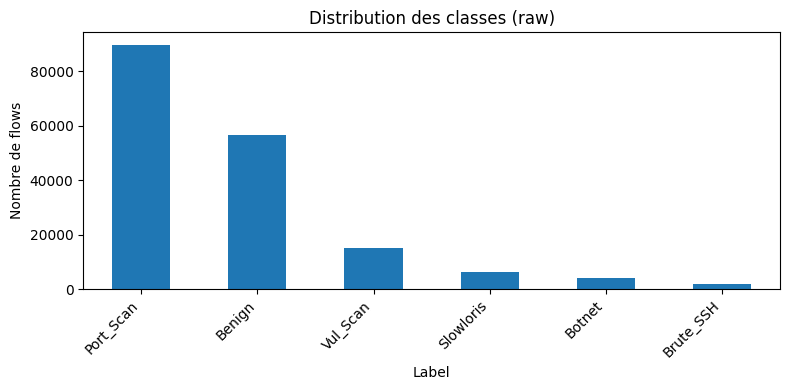

In [5]:
miss_pct = (df_all.isna().sum().sum() / df_all.size) * 100
print(f'Missing values : {miss_pct:.4f}%')

df_all.replace([np.inf, -np.inf], np.nan, inplace=True)
df_all.dropna(inplace=True)
df_all.reset_index(drop=True, inplace=True)

# Distribution classes
class_dist = df_all['Label'].value_counts()
print('\nDistribution :')
print(class_dist)

plt.figure(figsize=(8, 4))
class_dist.plot(kind='bar')
plt.title('Distribution des classes (raw)')
plt.ylabel('Nombre de flows')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Suppression features redondantes / overfitting
> Colonnes identiques au notebook original + features qui leakent (IP, port brut, subflows redondants)

In [6]:
# ── Features à supprimer (redondantes, leakage, variance nulle)
DROP_STATIC = [
    # Redondances directes
    'fwd_pkts_s', 'bwd_pkts_s',           # déjà dans flow_pkts_s
    'fwd_iat_tot',                          # = sum(fwd_iat_*)
    'fwd_iat_max', 'fwd_iat_min',          # redondant avec flow_iat_*
    'bwd_iat_min',
    'fwd_header_len', 'bwd_header_len',    # quasi-constant TCP
    'fwd_pkt_len_std',                      # redondant avec pkt_len_std
    'pkt_len_std',                          # pkt_len_var = std²
    'syn_flag_cnt', 'ece_flag_cnt',        # très rares
    'pkt_size_avg',                         # = totlen / nb_pkts (redondant)
    'fwd_seg_size_avg', 'bwd_seg_size_avg',# = header_len (redondant)
    'subflow_fwd_pkts', 'subflow_bwd_pkts',# = tot_fwd/bwd dans CIC
    'subflow_fwd_byts', 'subflow_bwd_byts',
    'active_max', 'idle_max', 'idle_min',  # corrélés à active_mean/idle_mean
    'totlen_bwd_pkts',                      # redondant bwd_pkt_len * tot_bwd
]

cols_to_drop = [c for c in DROP_STATIC if c in df_all.columns]
df_all.drop(columns=cols_to_drop, inplace=True)
print(f'Features supprimées (statique) : {len(cols_to_drop)}')
print(f'Features restantes : {len([c for c in df_all.columns if c != "Label"])}')

Features supprimées (statique) : 23
Features restantes : 56


## 7. Nettoyage par corrélation (seuil > 0.95)

Features supprimées par corrélation (>0.95) : 10
['pkt_len_max', 'fwd_act_data_pkts', 'fwd_iat_mean', 'fwd_iat_std', 'bwd_iat_tot', 'bwd_iat_max', 'fwd_psh_flags', 'psh_flag_cnt', 'ack_flag_cnt', 'fwd_pkts_b_avg']

✅ Features finales : 46


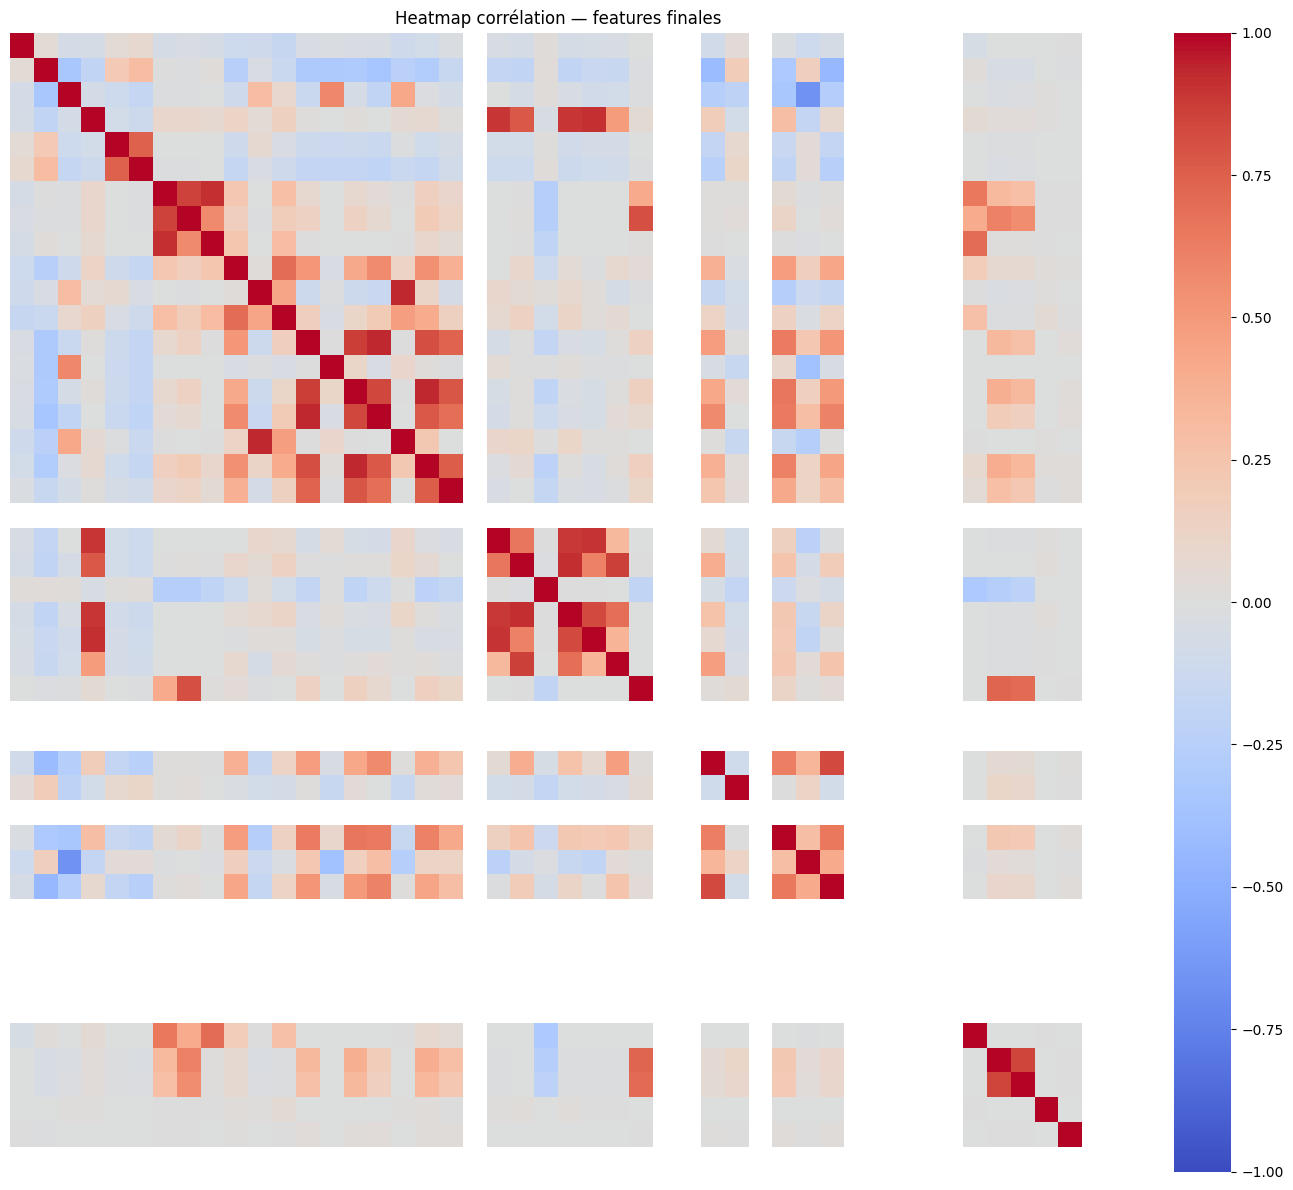

In [7]:
feature_cols_tmp = [c for c in df_all.columns if c != 'Label']

corr_matrix = df_all[feature_cols_tmp].astype('float32').corr().abs()

# Matrice triangulaire supérieure
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Features avec corrélation > 0.95
to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.95)]

print(f'Features supprimées par corrélation (>0.95) : {len(to_drop_corr)}')
print(to_drop_corr)

df_all.drop(columns=to_drop_corr, inplace=True)

# Heatmap corrélation (features restantes)
feature_cols_final = [c for c in df_all.columns if c != 'Label']
print(f'\n✅ Features finales : {len(feature_cols_final)}')

plt.figure(figsize=(14, 12))
sns.heatmap(
    df_all[feature_cols_final].astype('float32').corr(),
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    xticklabels=False, yticklabels=False
)
plt.title('Heatmap corrélation — features finales')
plt.tight_layout()
plt.show()

## 8. Encodage Protocol (One-Hot) + Port binning

In [8]:
# ── Protocol : One-Hot
if 'protocol' in df_all.columns:
    df_all['protocol'] = pd.to_numeric(df_all['protocol'], errors='coerce')
    df_all.dropna(subset=['protocol'], inplace=True)
    df_all['protocol'] = df_all['protocol'].astype(int)
    df_all = pd.get_dummies(df_all, columns=['protocol'], prefix='proto', dtype=np.int8)
    print(f'Colonnes proto : {[c for c in df_all.columns if "proto" in c]}')

# ── dst_port : binning
COMMON_PORTS = {80, 443, 53, 21, 22, 25, 110, 143, 3306, 5432}

def port_bin(port):
    if port in COMMON_PORTS: return 0   # port connu
    elif port < 1024:         return 1   # port système
    elif port < 49152:        return 2   # port enregistré
    else:                     return 3   # port éphémère

if 'dst_port' in df_all.columns:
    df_all['port_bin'] = df_all['dst_port'].apply(port_bin)
    df_all = pd.get_dummies(df_all, columns=['port_bin'], prefix='port', dtype=np.int8)
    df_all.drop(columns=['dst_port'], inplace=True, errors='ignore')

if 'src_port' in df_all.columns:
    df_all.drop(columns=['src_port'], inplace=True)

print(f'Shape après encodage : {df_all.shape}')

Colonnes proto : ['proto_6', 'proto_17']
Shape après encodage : (174025, 50)


In [9]:
df_all

,flow_duration,flow_byts_s,flow_pkts_s,tot_fwd_pkts,tot_bwd_pkts,totlen_fwd_pkts,fwd_pkt_len_max,fwd_pkt_len_min,fwd_pkt_len_mean,bwd_pkt_len_max,...,fwd_blk_rate_avg,bwd_blk_rate_avg,cwr_flag_count,Label,proto_6,proto_17,port_0,port_1,port_2,port_3
0,54.505066,6.042536e+04,60.838383,808,2508,138103,1294,71,170.919556,1294,...,4.067401e+03,9072829.0,0,Benign,0,1,1,0,0,0
1,0.034763,8.831229e+03,86.298653,2,1,164,82,82,82.000000,143,...,0.000000e+00,0.0,0,Benign,0,1,1,0,0,0
2,0.093203,7.240110e+04,321.878052,16,14,3817,2535,66,238.562500,1454,...,1.026528e+05,1518288.0,0,Benign,1,0,1,0,0,0
3,0.093373,6.898140e+04,278.453094,14,12,3654,2535,66,261.000000,1924,...,0.000000e+00,0.0,0,Benign,1,0,1,0,0,0
4,47.139561,3.672287e+02,1.081894,25,26,14861,1294,74,594.440002,252,...,3.932000e+09,0.0,0,Benign,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174020,0.031180,4.403464e+04,352.790253,6,5,515,169,66,85.833336,401,...,0.000000e+00,0.0,0,Vul_Scan,1,0,1,0,0,0
174021,0.034573,3.968415e+04,318.167358,6,5,514,168,66,85.666664,401,...,0.000000e+00,0.0,0,Vul_Scan,1,0,1,0,0,0
174022,0.042689,3.195203e+04,257.677612,6,5,506,160,66,84.333336,401,...,0.000000e+00,0.0,0,Vul_Scan,1,0,1,0,0,0
174023,0.000000,0.000000e+00,0.000000,2,0,148,74,74,74.000000,0,...,0.000000e+00,0.0,0,Vul_Scan,1,0,1,0,0,0


## 9. Encodage Label (One-Hot)

In [10]:
LABELS_COLS = sorted(df_all['Label'].unique().tolist())
# Mettre Benign en premier
if 'Benign' in LABELS_COLS:
    LABELS_COLS = ['Benign'] + [l for l in LABELS_COLS if l != 'Benign']

print(f'Classes : {LABELS_COLS}')

combined_labels = pd.get_dummies(df_all['Label'], prefix='', prefix_sep='', dtype=np.int8)
# Réordonner selon LABELS_COLS
combined_labels = combined_labels.reindex(columns=LABELS_COLS, fill_value=0)

df_all = pd.concat([df_all.drop(columns=['Label']), combined_labels], axis=1)

feature_cols = [c for c in df_all.columns if c not in LABELS_COLS]

print(f'Features : {len(feature_cols)}')
print(f'Classes  : {len(LABELS_COLS)}')
print(f'Shape df : {df_all.shape}')

Classes : ['Benign', 'Botnet', 'Brute_SSH', 'Port_Scan', 'Slowloris', 'Vul_Scan']
Features : 49
Classes  : 6
Shape df : (174025, 55)


## 10. Fenêtres temporelles (window_size=10, step=1)

X_windows : (174016, 10, 49)
y_windows : (174016, 6)


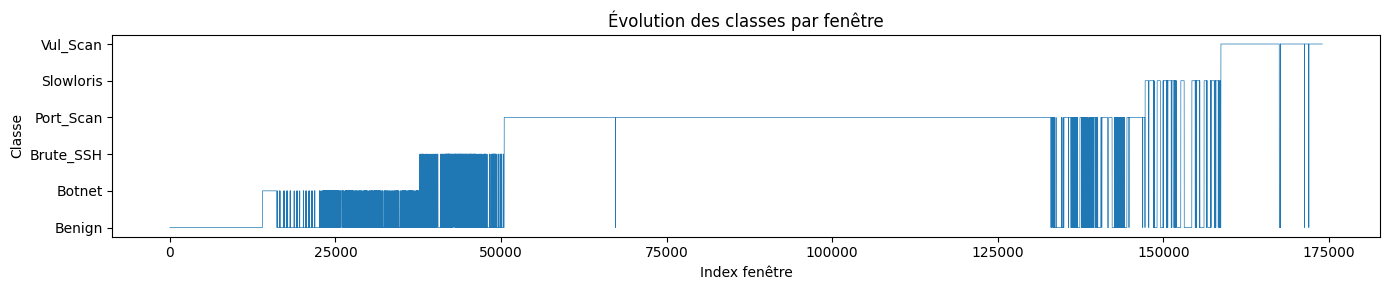


Répartition après step=1 :
  Benign               : 49910
  Botnet               : 6721
  Brute_SSH            : 3790
  Port_Scan            : 91568
  Slowloris            : 6863
  Vul_Scan             : 15164


3093

In [11]:
def create_windows_multilabel(
    df,
    features_cols,
    label_cols,
    window_size=10,
    step=1,              # ← step=1 pour maximiser les fenêtres minoritaires
    attack_threshold=0.1
):
    X = []
    y = []

    data_feat = df[features_cols].values
    data_labs = df[label_cols].values

    benign_idx  = label_cols.index('Benign')
    attack_mask = np.ones(len(label_cols), dtype=bool)
    attack_mask[benign_idx] = False

    for i in range(0, len(df) - window_size + 1, step):
        window        = data_feat[i : i + window_size]
        window_labels = data_labs[i : i + window_size]

        attack_count = window_labels[:, attack_mask].sum()
        attack_ratio = attack_count / window_size

        if attack_ratio > attack_threshold:
            attack_counts  = window_labels[:, attack_mask].sum(axis=0)
            attack_classes = np.array(label_cols)[attack_mask]
            target_class   = attack_classes[np.argmax(attack_counts)]
        else:
            target_class = 'Benign'

        target = np.zeros(len(label_cols))
        target[label_cols.index(target_class)] = 1

        X.append(window)
        y.append(target)

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


WINDOW_SIZE = 10
STEP        = 1          # ← modifié (était 10)

X_windows, y_windows = create_windows_multilabel(
    df_all, feature_cols, LABELS_COLS,
    window_size=WINDOW_SIZE, step=STEP
)

print(f'X_windows : {X_windows.shape}')   # (N, 10, F)
print(f'y_windows : {y_windows.shape}')   # (N, C)

# Visualisation évolution classes
y_classes = np.argmax(y_windows, axis=1)
plt.figure(figsize=(14, 3))
plt.plot(y_classes, linewidth=0.5)
plt.title('Évolution des classes par fenêtre')
plt.xlabel('Index fenêtre')
plt.ylabel('Classe')
plt.yticks(range(len(LABELS_COLS)), LABELS_COLS)
plt.tight_layout()
plt.show()

print('\nRépartition après step=1 :')
for i, name in enumerate(LABELS_COLS):
    print(f'  {name:20} : {int(y_windows[:, i].sum())}')

del df_all
gc.collect()


## 11. Train / Test split

In [12]:
y_labels = np.argmax(y_windows, axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X_windows, y_windows,
    test_size=0.2,
    random_state=SEED,
    stratify=y_labels
)

print(f'Train : {X_train.shape}')
print(f'Test  : {X_test.shape}')

del X_windows, y_windows
gc.collect()

Train : (139212, 10, 49)
Test  : (34804, 10, 49)


0

## 12. Rééquilibrage (undersample majorités + SMOTE minoritaires)

In [13]:
y_train_labels = np.argmax(y_train, axis=1)

# ── Distribution avant rééquilibrage
counts = {i: int((y_train_labels == i).sum()) for i in range(len(LABELS_COLS))}
print('Distribution avant rééquilibrage :')
for i, name in enumerate(LABELS_COLS):
    print(f'  {name:20} : {counts[i]:>6}')

# ── Undersample Benign, Port_Scan et Vul_Scan si trop dominants
BENIGN_TARGET    = 6000
PORT_SCAN_TARGET = 6000
VUL_SCAN_TARGET  = 6000   # ←

X_res_list, y_res_list = [], []
for i, name in enumerate(LABELS_COLS):
    indices = np.where(y_train_labels == i)[0]
    if len(indices) == 0:
        continue

    if name == 'Benign' and len(indices) > BENIGN_TARGET:
        new_idx = resample(indices, replace=False, n_samples=BENIGN_TARGET, random_state=SEED)
        print(f'{name:20} : {len(indices):>6} → {len(new_idx)} (undersample)')
    elif name == 'Port_Scan' and len(indices) > PORT_SCAN_TARGET:
        new_idx = resample(indices, replace=False, n_samples=PORT_SCAN_TARGET, random_state=SEED)
        print(f'{name:20} : {len(indices):>6} → {len(new_idx)} (undersample)')
    elif name == 'Vul_Scan' and len(indices) > VUL_SCAN_TARGET:   # ←
        new_idx = resample(indices, replace=False, n_samples=VUL_SCAN_TARGET, random_state=SEED)   # ←
        print(f'{name:20} : {len(indices):>6} → {len(new_idx)} (undersample)')   # ←
    else:
        new_idx = indices
        print(f'{name:20} : {len(indices):>6} (kept)')

    X_res_list.append(X_train[new_idx])
    y_res_list.append(y_train[new_idx])

X_pre = np.vstack(X_res_list).astype(np.float32)
y_pre = np.vstack(y_res_list).astype(np.float32)
del X_res_list, y_res_list
gc.collect()

# ── SMOTE sur les classes minoritaires
N, T, F = X_pre.shape
X_flat  = X_pre.reshape(N, T * F)
y_idx   = np.argmax(y_pre, axis=1)

SMOTE_TARGET = 1500

counts_pre = {i: int((y_idx == i).sum()) for i in range(len(LABELS_COLS))}
sampling_strategy = {
    i: SMOTE_TARGET
    for i in range(len(LABELS_COLS))
    if counts_pre[i] < SMOTE_TARGET and counts_pre[i] > 0
}

print(f'\nSMOTE — cible par classe minoritaire : {SMOTE_TARGET}')
print(f'Classes concernées : {[LABELS_COLS[i] for i in sampling_strategy]}')

if sampling_strategy:
    k = min(5, min(counts_pre[i] for i in sampling_strategy) - 1)
    sm = SMOTE(
        sampling_strategy=sampling_strategy,
        k_neighbors=max(1, k),
        random_state=SEED
    )
    X_res_flat, y_res_idx = sm.fit_resample(X_flat, y_idx)
else:
    print('Aucune classe sous le seuil SMOTE_TARGET — pas de SMOTE.')
    X_res_flat, y_res_idx = X_flat, y_idx

# Reshape vers (N, T, F)
X_train_final = X_res_flat.reshape(-1, T, F).astype(np.float32)

# Reconstruire y one-hot
y_train_final = np.zeros((len(y_res_idx), len(LABELS_COLS)), dtype=np.float32)
y_train_final[np.arange(len(y_res_idx)), y_res_idx] = 1.0

# Shuffle
idx = np.random.permutation(len(X_train_final))
X_train_final = X_train_final[idx]
y_train_final = y_train_final[idx]

del X_pre, y_pre, X_flat, X_res_flat
gc.collect()

print('\nDistribution finale train :')
for i, name in enumerate(LABELS_COLS):
    print(f'  {name:20} : {int(y_train_final[:, i].sum())}')
print(f'\nX_train_final : {X_train_final.shape}')

Distribution avant rééquilibrage :
  Benign               :  39928
  Botnet               :   5377
  Brute_SSH            :   3032
  Port_Scan            :  73254
  Slowloris            :   5490
  Vul_Scan             :  12131
Benign               :  39928 → 6000 (undersample)
Botnet               :   5377 (kept)
Brute_SSH            :   3032 (kept)
Port_Scan            :  73254 → 6000 (undersample)
Slowloris            :   5490 (kept)
Vul_Scan             :  12131 → 6000 (undersample)

SMOTE — cible par classe minoritaire : 1500
Classes concernées : []
Aucune classe sous le seuil SMOTE_TARGET — pas de SMOTE.

Distribution finale train :
  Benign               : 6000
  Botnet               : 5377
  Brute_SSH            : 3032
  Port_Scan            : 6000
  Slowloris            : 5490
  Vul_Scan             : 6000

X_train_final : (31899, 10, 49)


## 13. Normalisation (StandardScaler)

In [14]:
scaler = StandardScaler()

N_tr, T_tr, F = X_train_final.shape
X_train_scaled = scaler.fit_transform(
    X_train_final.reshape(-1, F)
).reshape(N_tr, T_tr, F).astype(np.float32)

N_te, T_te, _ = X_test.shape
X_test_scaled = scaler.transform(
    X_test.reshape(-1, F)
).reshape(N_te, T_te, F).astype(np.float32)

joblib.dump(scaler, 'scaler_ids_transformer.pkl')
print(f'✅ Scaler sauvegardé')
print(f'X_train_scaled : {X_train_scaled.shape}')
print(f'X_test_scaled  : {X_test_scaled.shape}')

✅ Scaler sauvegardé
X_train_scaled : (31899, 10, 49)
X_test_scaled  : (34804, 10, 49)


## 14. Architecture Transformer

In [15]:
class NetflowTransformer(nn.Module):
    def __init__(
        self, input_dim, num_classes,
        model_dim=64, num_heads=4,
        num_layers=2, seq_len=10, dropout=0.3
    ):
        super().__init__()

        self.input_projection = nn.Linear(input_dim, model_dim)

        # Positional encoding appris
        self.pos_embedding = nn.Parameter(
            torch.randn(1, seq_len, model_dim) * 0.02
        )

        self.input_norm = nn.LayerNorm(model_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=model_dim,
            nhead=num_heads,
            dim_feedforward=model_dim * 4,
            dropout=dropout,
            batch_first=True,
            norm_first=True       # Pre-LN : plus stable
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers
        )

        self.post_norm = nn.LayerNorm(model_dim)

        # Attention pooling
        self.pool = nn.Linear(model_dim, 1)

        self.classifier = nn.Sequential(
            nn.Linear(model_dim, model_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(model_dim // 2, num_classes)
        )

    def forward(self, x):
        x = self.input_projection(x)
        x = x + self.pos_embedding[:, :x.size(1), :]
        x = self.input_norm(x)
        x = self.transformer_encoder(x)
        x = self.post_norm(x)

        # Attention pooling (pondéré)
        attn = torch.softmax(self.pool(x), dim=1)
        x = torch.sum(x * attn, dim=1)

        return self.classifier(x)


# Test rapide
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')

_m = NetflowTransformer(
    input_dim=X_train_scaled.shape[2],
    num_classes=len(LABELS_COLS)
).to(device)

_x = torch.randn(4, WINDOW_SIZE, X_train_scaled.shape[2]).to(device)
print(f'Output shape : {_m(_x).shape}')   # (4, nb_classes)
del _m, _x

Device : cpu
Output shape : torch.Size([4, 6])


## 15. DataLoaders + Entraînement

In [16]:
gc.collect()

BATCH_SIZE = 128
EPOCHS     = 20
PATIENCE   = 5
LR         = 3e-4

train_loader = DataLoader(
    TensorDataset(
        torch.from_numpy(X_train_scaled),
        torch.from_numpy(y_train_final)
    ),
    batch_size=BATCH_SIZE, shuffle=True,
    pin_memory=True, drop_last=True
)

test_loader = DataLoader(
    TensorDataset(
        torch.from_numpy(X_test_scaled),
        torch.from_numpy(y_test.astype(np.float32))
    ),
    batch_size=BATCH_SIZE, shuffle=False, pin_memory=True
)

model = NetflowTransformer(
    input_dim=X_train_scaled.shape[2],
    num_classes=len(LABELS_COLS)
).to(device)

# ── Class weights pour pénaliser davantage les erreurs sur classes rares
y_idx_train = np.argmax(y_train_final, axis=1)
weights = compute_class_weight('balanced', classes=np.arange(len(LABELS_COLS)), y=y_idx_train)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)
print(f'Class weights : {dict(zip(LABELS_COLS, weights.round(3)))}')

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    model.parameters(), lr=LR, weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6
)

history = {
    'train_loss': [], 'train_acc': [], 'train_f1': [],
    'test_loss' : [], 'test_acc' : [], 'test_f1' : []
}

best_f1  = -1
counter  = 0

print(f'Paramètres modèle : {sum(p.numel() for p in model.parameters()):,}')
print(f'Début entraînement — {EPOCHS} epochs max\n')

for epoch in range(EPOCHS):

    # ── TRAIN
    model.train()
    total_loss = correct = total = 0
    all_preds_tr, all_tgts_tr = [], []

    for bX, by in train_loader:
        bX, by = bX.to(device, non_blocking=True), by.to(device, non_blocking=True)
        optimizer.zero_grad()
        out     = model(bX)
        targets = by.argmax(dim=1)
        loss    = criterion(out, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        preds       = out.argmax(dim=1)
        total      += targets.size(0)
        correct    += (preds == targets).sum().item()
        all_preds_tr.append(preds.detach().cpu().numpy())
        all_tgts_tr.append(targets.detach().cpu().numpy())

    all_preds_tr = np.concatenate(all_preds_tr)
    all_tgts_tr  = np.concatenate(all_tgts_tr)
    tr_loss = total_loss / len(train_loader)
    tr_acc  = 100 * correct / total
    tr_f1   = f1_score(all_tgts_tr, all_preds_tr, average='macro') * 100

    # ── TEST
    model.eval()
    te_loss = te_correct = te_total = 0
    all_preds_te, all_tgts_te = [], []

    with torch.no_grad():
        for bX, by in test_loader:
            bX, by = bX.to(device, non_blocking=True), by.to(device, non_blocking=True)
            out     = model(bX)
            targets = by.argmax(dim=1)
            loss    = criterion(out, targets)
            te_loss += loss.item()
            preds    = out.argmax(dim=1)
            te_total   += targets.size(0)
            te_correct += (preds == targets).sum().item()
            all_preds_te.append(preds.cpu().numpy())
            all_tgts_te.append(targets.cpu().numpy())

    all_preds_te = np.concatenate(all_preds_te)
    all_tgts_te  = np.concatenate(all_tgts_te)
    te_loss = te_loss / len(test_loader)
    te_acc  = 100 * te_correct / te_total
    te_f1   = f1_score(all_tgts_te, all_preds_te, average='macro') * 100

    scheduler.step()

    for k, v in zip(
        ['train_loss','train_acc','train_f1','test_loss','test_acc','test_f1'],
        [tr_loss, tr_acc, tr_f1, te_loss, te_acc, te_f1]
    ):
        history[k].append(v)

    print(f'Epoch {epoch+1:02d}/{EPOCHS} | '
          f'TRAIN loss {tr_loss:.4f} acc {tr_acc:.1f}% f1 {tr_f1:.1f}% | '
          f'TEST  loss {te_loss:.4f} acc {te_acc:.1f}% f1 {te_f1:.1f}%')

    # Early stopping
    if te_f1 > best_f1:
        best_f1 = te_f1
        torch.save(model.state_dict(), 'best_ids_transformer.pth')
        counter = 0
        print(f'  ✅ Meilleur modèle sauvegardé (F1={best_f1:.2f}%)')
    else:
        counter += 1
        if counter >= PATIENCE:
            print(f'\n⛔ Early stopping à epoch {epoch+1}')
            break

print(f'\n✅ Best Test F1 (macro) : {best_f1:.2f}%')

Class weights : {'Benign': np.float64(0.886), 'Botnet': np.float64(0.989), 'Brute_SSH': np.float64(1.753), 'Port_Scan': np.float64(0.886), 'Slowloris': np.float64(0.968), 'Vul_Scan': np.float64(0.886)}
Paramètres modèle : 106,407
Début entraînement — 20 epochs max

Epoch 01/20 | TRAIN loss 0.5342 acc 89.6% f1 88.8% | TEST  loss 0.1287 acc 96.3% f1 91.5%
  ✅ Meilleur modèle sauvegardé (F1=91.48%)
Epoch 02/20 | TRAIN loss 0.1158 acc 97.6% f1 97.5% | TEST  loss 0.0550 acc 98.2% f1 95.8%
  ✅ Meilleur modèle sauvegardé (F1=95.76%)
Epoch 03/20 | TRAIN loss 0.0595 acc 98.6% f1 98.5% | TEST  loss 0.0317 acc 99.1% f1 98.0%
  ✅ Meilleur modèle sauvegardé (F1=98.00%)
Epoch 04/20 | TRAIN loss 0.0414 acc 99.0% f1 98.9% | TEST  loss 0.0504 acc 98.3% f1 96.0%
Epoch 05/20 | TRAIN loss 0.0349 acc 99.1% f1 99.0% | TEST  loss 0.0408 acc 98.6% f1 96.5%
Epoch 06/20 | TRAIN loss 0.0315 acc 99.2% f1 99.1% | TEST  loss 0.0313 acc 99.0% f1 97.6%
Epoch 07/20 | TRAIN loss 0.0251 acc 99.3% f1 99.3% | TEST  loss 0

## 16. Courbes d'apprentissage

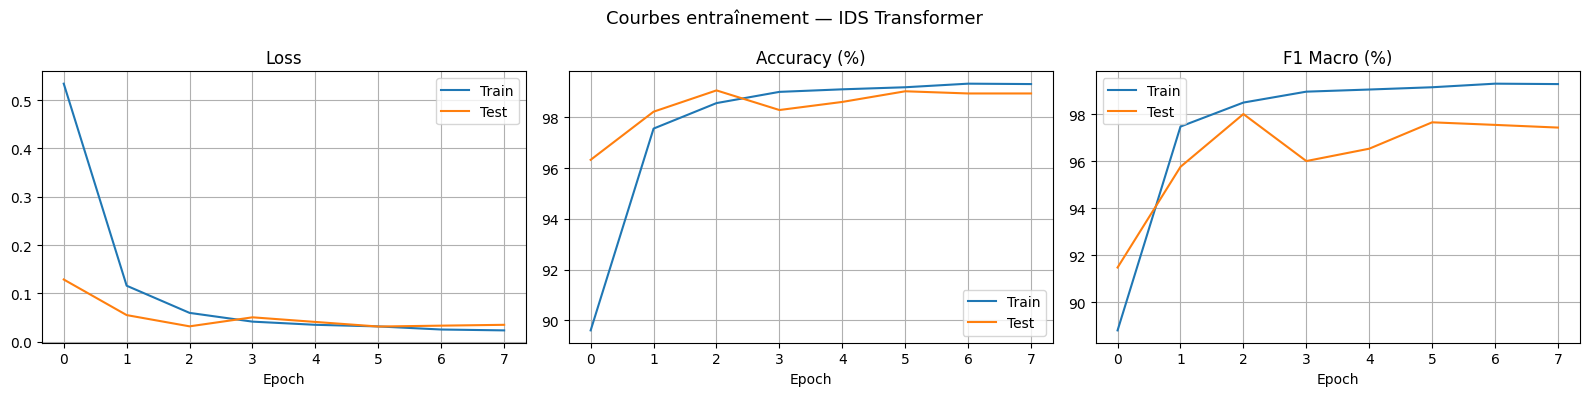

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, metric, title in zip(
    axes,
    [('train_loss','test_loss'), ('train_acc','test_acc'), ('train_f1','test_f1')],
    ['Loss', 'Accuracy (%)', 'F1 Macro (%)']
):
    ax.plot(history[metric[0]], label='Train')
    ax.plot(history[metric[1]], label='Test')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True)

plt.suptitle('Courbes entraînement — IDS Transformer', fontsize=13)
plt.tight_layout()
plt.show()

## 17. Évaluation finale

In [18]:
# Charger le meilleur modèle
model.load_state_dict(torch.load('best_ids_transformer.pth', map_location=device))
model.eval()

y_true_list, y_pred_list = [], []

with torch.no_grad():
    for bX, by in test_loader:
        bX = bX.to(device, non_blocking=True)
        out = model(bX)
        y_pred_list.extend(out.argmax(dim=1).cpu().numpy())
        y_true_list.extend(by.argmax(dim=1).numpy())

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)

print('\n📊 Classification Report :')
print(classification_report(
    y_true, y_pred,
    target_names=LABELS_COLS,
    zero_division=0
))


📊 Classification Report :
              precision    recall  f1-score   support

      Benign       0.99      0.98      0.99      9982
      Botnet       0.97      0.99      0.98      1344
   Brute_SSH       0.89      1.00      0.94       758
   Port_Scan       1.00      0.99      1.00     18314
   Slowloris       0.96      0.99      0.97      1373
    Vul_Scan       1.00      1.00      1.00      3033

    accuracy                           0.99     34804
   macro avg       0.97      0.99      0.98     34804
weighted avg       0.99      0.99      0.99     34804



## 18. Matrice de confusion

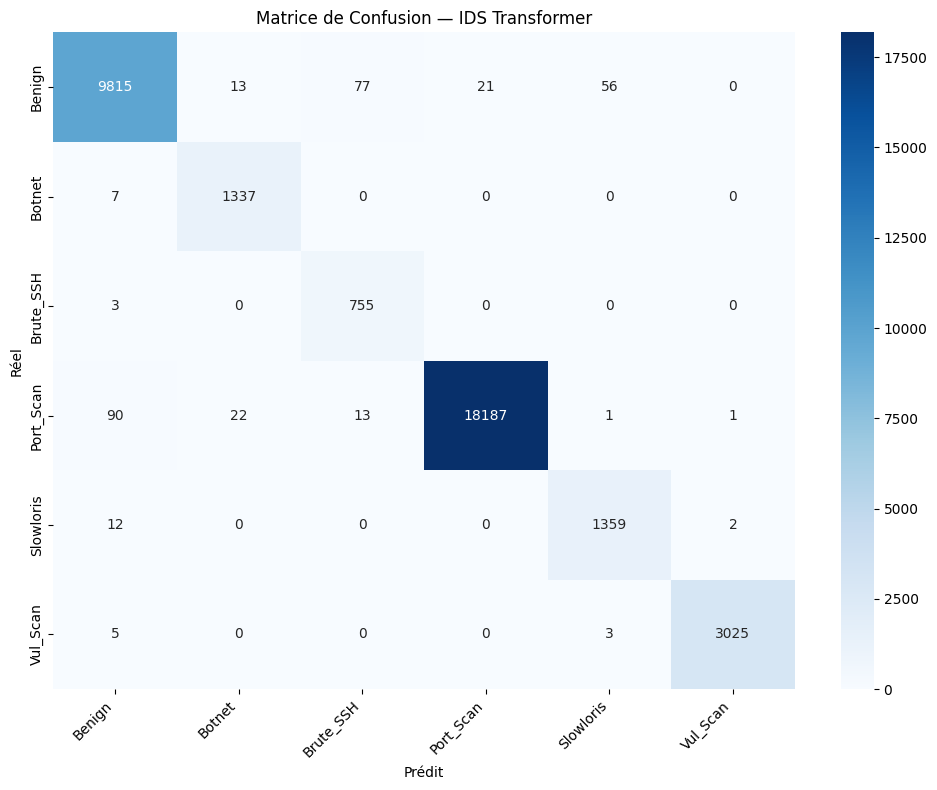

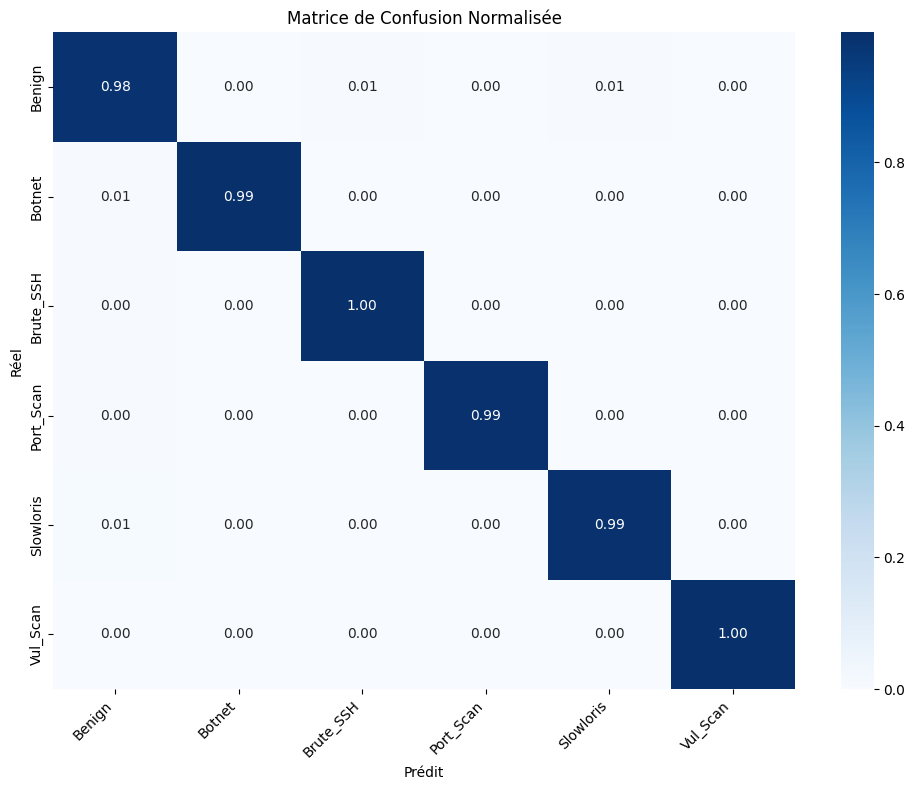

In [19]:
cm = confusion_matrix(y_true, y_pred)

# Brute
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS_COLS, yticklabels=LABELS_COLS)
plt.title('Matrice de Confusion — IDS Transformer')
plt.xlabel('Prédit'); plt.ylabel('Réel')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Normalisée
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm  = np.divide(cm.astype('float'), row_sums,
                     out=np.zeros_like(cm, dtype=float),
                     where=row_sums != 0)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=LABELS_COLS, yticklabels=LABELS_COLS)
plt.title('Matrice de Confusion Normalisée')
plt.xlabel('Prédit'); plt.ylabel('Réel')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 19. Test robustesse (bruit gaussien)

In [20]:
from sklearn.metrics import accuracy_score

noise_level = 0.1
X_test_noisy = X_test_scaled + np.random.normal(0, noise_level, X_test_scaled.shape).astype(np.float32)

noisy_loader = DataLoader(
    TensorDataset(
        torch.from_numpy(X_test_noisy),
        torch.from_numpy(y_test.astype(np.float32))
    ),
    batch_size=BATCH_SIZE, shuffle=False
)

model.eval()
n_preds, n_tgts = [], []

with torch.no_grad():
    for bX, by in noisy_loader:
        out = model(bX.to(device))
        n_preds.append(out.argmax(dim=1).cpu().numpy())
        n_tgts.append(by.argmax(dim=1).numpy())

n_preds = np.concatenate(n_preds)
n_tgts  = np.concatenate(n_tgts)

print(f'🔥 Robustesse au bruit (σ={noise_level})')
print(f'   Accuracy : {accuracy_score(n_tgts, n_preds)*100:.2f}%')
print(f'   F1 macro : {f1_score(n_tgts, n_preds, average="macro")*100:.2f}%')

🔥 Robustesse au bruit (σ=0.1)
   Accuracy : 99.00%
   F1 macro : 97.91%


## 20. Sauvegarde

In [21]:
torch.save(model.state_dict(), 'ids_transformer_final.pth')
joblib.dump(scaler, 'scaler_ids_transformer.pkl')

import json
meta = {
    'labels'      : LABELS_COLS,
    'features'    : feature_cols,
    'window_size' : WINDOW_SIZE,
    'input_dim'   : X_train_scaled.shape[2],
    'num_classes' : len(LABELS_COLS),
    'best_f1'     : round(best_f1, 4)
}
with open('model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('✅ Tout sauvegardé :')
print('   ids_transformer_final.pth')
print('   scaler_ids_transformer.pkl')
print('   model_meta.json')

✅ Tout sauvegardé :
   ids_transformer_final.pth
   scaler_ids_transformer.pkl
   model_meta.json
